In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
# read dataset 
df = pd.read_csv("customer_churn_exam_dataset_3500.csv")
df.head()


,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
0,C0001,__35__,Male,South,Basic,16.62,2,5,__27.0__,Quarterly,Card,Yes,4,26,0,1,0
1,C0002,26,Male,North,Standard,46.23,__4__,0,46.1,Monthly,UPI,Yes,5,11,0,2,1
2,C0003,31,Female,North,Standard,43.04,32,0,27.2,NaN,UPI,Yes,7,6,2,3,0
3,C0004,34,Male,East,Basic,29.19,20,4,25.1,Monthly,Bank Transfer,Yes,4,19,0,4,0
4,C0005,38,Female,North,Basic,24.95,1,4,49,Monthly,Cash,No,3,25,0,3,1


In [5]:
df["Churn"].value_counts()

Churn
0    2933
1     567
Name: count, dtype: int64

In [6]:
df.shape

(3500, 17)

In [7]:
df.isna().sum()

CustomerID                0
Age                      72
Gender                   68
Region                   52
PlanType                 55
MonthlyCharges          112
TenureMonths             60
SupportTickets           66
AvgMonthlyUsageHours     98
ContractType             69
PaymentMethod            54
AutoPay                  60
SatisfactionScore        78
LastLoginDays            47
ReferralCount            25
DeviceCount              32
Churn                     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   CustomerID            3500 non-null   object
 1   Age                   3428 non-null   object
 2   Gender                3432 non-null   object
 3   Region                3448 non-null   object
 4   PlanType              3445 non-null   object
 5   MonthlyCharges        3388 non-null   object
 6   TenureMonths          3440 non-null   object
 7   SupportTickets        3434 non-null   object
 8   AvgMonthlyUsageHours  3402 non-null   object
 9   ContractType          3431 non-null   object
 10  PaymentMethod         3446 non-null   object
 11  AutoPay               3440 non-null   object
 12  SatisfactionScore     3422 non-null   object
 13  LastLoginDays         3453 non-null   object
 14  ReferralCount         3475 non-null   object
 15  DeviceCount           3468 non-null   

In [10]:
df.head()

,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
0,C0001,__35__,Male,South,Basic,16.62,2,5,__27.0__,Quarterly,Card,Yes,4,26,0,1,0
1,C0002,26,Male,North,Standard,46.23,__4__,0,46.1,Monthly,UPI,Yes,5,11,0,2,1
2,C0003,31,Female,North,Standard,43.04,32,0,27.2,NaN,UPI,Yes,7,6,2,3,0
3,C0004,34,Male,East,Basic,29.19,20,4,25.1,Monthly,Bank Transfer,Yes,4,19,0,4,0
4,C0005,38,Female,North,Basic,24.95,1,4,49,Monthly,Cash,No,3,25,0,3,1


In [11]:
print(df['Gender'].value_counts())

Gender
Female        1667
Male          1616
Non-binary     115
unknown         24
__value__       10
Name: count, dtype: int64


In [12]:
# Use [0] to get the string 'Female' instead of a Series object
mode_val = df['Gender'].mode()[0]

# Replace only the messy values
df['Gender'] = df['Gender'].replace(['unknown', '__value__'], mode_val)

# Optional: To also move 'Non-binary' into the mode to have only 2 categories
# df['Gender'] = df['Gender'].replace('Non-binary', mode_val)

print(df['Gender'].value_counts())

Gender
Female        1701
Male          1616
Non-binary     115
Name: count, dtype: int64


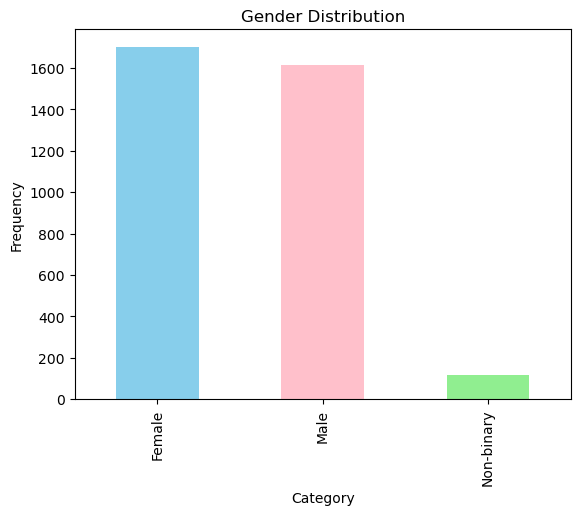

,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
0,C0001,__35__,1,South,3,16.62,2,5,__27.0__,Quarterly,Card,Yes,4,26,0,1,0
1,C0002,26,1,North,5,46.23,__4__,0,46.1,Monthly,UPI,Yes,5,11,0,2,1
2,C0003,31,0,North,5,43.04,32,0,27.2,NaN,UPI,Yes,7,6,2,3,0
3,C0004,34,1,East,3,29.19,20,4,25.1,Monthly,Bank Transfer,Yes,4,19,0,4,0
4,C0005,38,0,North,3,24.95,1,4,49,Monthly,Cash,No,3,25,0,3,1


In [13]:
import matplotlib.pyplot as plt

df['Gender'].value_counts().plot(kind='bar', color=['skyblue', 'pink', 'lightgreen'])
plt.title('Gender Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()
from sklearn.preprocessing import LabelEncoder
# Initialize the encoder
le = LabelEncoder()
df["Gender"]= le.fit_transform(df["Gender"])
df["PlanType"]= le.fit_transform(df["PlanType"])
df.head()

In [14]:
df.isnull().sum()

CustomerID                0
Age                      72
Gender                    0
Region                   52
PlanType                  0
MonthlyCharges          112
TenureMonths             60
SupportTickets           66
AvgMonthlyUsageHours     98
ContractType             69
PaymentMethod            54
AutoPay                  60
SatisfactionScore        78
LastLoginDays            47
ReferralCount            25
DeviceCount              32
Churn                     0
dtype: int64

In [15]:
import pandas as pd
import re

# 1. Clean and Impute Numerical Columns (Median)
num_cols = ['Age', 'MonthlyCharges', 'AvgMonthlyUsageHours', 'TenureMonths', 'SupportTickets']

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[#_":$a-zA-Z]', '', regex=True) # Remove symbols and letters
        .str.extract(r'(\d+\.?\d*)')[0]                # Extract number
        .pipe(pd.to_numeric, errors='coerce')          # Convert to numeric
    )
    # Fill missing values with Median
    df[col] = df[col].fillna(df[col].median())

# 2. Clean and Impute Categorical Columns (Mode)
cat_cols = ['Region', 'PaymentMethod', 'AutoPay', 'ContractType']

for col in cat_cols:
    # Basic string cleanup for categories (remove punctuation noise)
    df[col] = df[col].astype(str).str.replace(r'[#_":]', '', regex=True).str.strip()
    
    # Handle 'nan' strings created by astype(str)
    df[col] = df[col].replace(['nan', 'None', 'unknown', ''], pd.NA)
    
    # Fill missing values with Mode
    df[col] = df[col].fillna(df[col].mode()[0])



In [16]:
# 3. Verify
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
CustomerID               0
Age                      0
Gender                   0
Region                   0
PlanType                 0
MonthlyCharges           0
TenureMonths             0
SupportTickets           0
AvgMonthlyUsageHours     0
ContractType             0
PaymentMethod            0
AutoPay                  0
SatisfactionScore       78
LastLoginDays           47
ReferralCount           25
DeviceCount             32
Churn                    0
dtype: int64


In [17]:
# List of columns to fix
cols_to_fix = ['SatisfactionScore', 'LastLoginDays', 'ReferralCount', 'DeviceCount']

for col in cols_to_fix:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[#_":]', '', regex=True) # Remove the noise
        .str.extract(r'(\d+\.?\d*)')[0]         # Extract only the numbers
        .pipe(pd.to_numeric, errors='coerce')   # Convert to float/int
    )
    # Fill the missing values (78, 47, 25, 32) with the Median
    df[col] = df[col].fillna(df[col].median())

# Check results
print(df[cols_to_fix].isnull().sum())

SatisfactionScore    0
LastLoginDays        0
ReferralCount        0
DeviceCount          0
dtype: int64


In [18]:
df.isnull().sum()

CustomerID              0
Age                     0
Gender                  0
Region                  0
PlanType                0
MonthlyCharges          0
TenureMonths            0
SupportTickets          0
AvgMonthlyUsageHours    0
ContractType            0
PaymentMethod           0
AutoPay                 0
SatisfactionScore       0
LastLoginDays           0
ReferralCount           0
DeviceCount             0
Churn                   0
dtype: int64

In [19]:
df.head()

,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
0,C0001,35.0,1,South,3,16.62,2.0,5.0,27.0,Quarterly,Card,Yes,4.0,26.0,0.0,1.0,0
1,C0002,26.0,1,North,5,46.23,4.0,0.0,46.1,Monthly,UPI,Yes,5.0,11.0,0.0,2.0,1
2,C0003,31.0,0,North,5,43.04,32.0,0.0,27.2,Monthly,UPI,Yes,7.0,6.0,2.0,3.0,0
3,C0004,34.0,1,East,3,29.19,20.0,4.0,25.1,Monthly,Bank Transfer,Yes,4.0,19.0,0.0,4.0,0
4,C0005,38.0,0,North,3,24.95,1.0,4.0,49.0,Monthly,Cash,No,3.0,25.0,0.0,3.0,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            3500 non-null   object 
 1   Age                   3500 non-null   float64
 2   Gender                3500 non-null   int32  
 3   Region                3500 non-null   object 
 4   PlanType              3500 non-null   int32  
 5   MonthlyCharges        3500 non-null   float64
 6   TenureMonths          3500 non-null   float64
 7   SupportTickets        3500 non-null   float64
 8   AvgMonthlyUsageHours  3500 non-null   float64
 9   ContractType          3500 non-null   object 
 10  PaymentMethod         3500 non-null   object 
 11  AutoPay               3500 non-null   object 
 12  SatisfactionScore     3500 non-null   float64
 13  LastLoginDays         3500 non-null   float64
 14  ReferralCount         3500 non-null   float64
 15  DeviceCount          

In [21]:
df.describe()

,Age,Gender,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,36.667143,0.585714,3.907429,40.100946,18.226000,2.996286,43.962486,5.171143,8.557714,1.198571,2.288571,0.162000
std,10.183585,0.651966,1.280585,22.194172,16.470072,2.259713,11.891415,2.059038,8.362216,1.349583,0.984960,0.368503
min,18.000000,0.000000,0.000000,8.500000,1.000000,0.000000,3.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,0.000000,3.000000,21.607500,6.000000,1.000000,36.000000,4.000000,0.000000,0.000000,2.000000,0.000000
50%,36.000000,1.000000,4.000000,37.585000,13.000000,3.000000,43.700000,5.000000,7.000000,1.000000,2.000000,0.000000
75%,43.000000,1.000000,5.000000,52.962500,25.000000,5.000000,51.700000,7.000000,14.000000,2.000000,3.000000,0.000000
max,70.000000,3.000000,8.000000,99.150000,72.000000,11.000000,87.500000,10.000000,50.000000,7.000000,6.000000,1.000000


<Axes: ylabel='Age'>

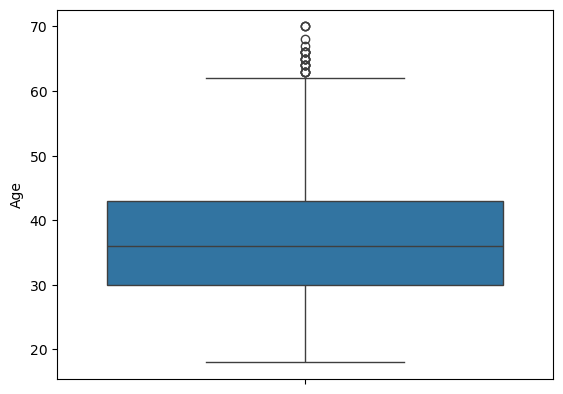

In [22]:
sns.boxplot(df["Age"])

<Axes: ylabel='Churn'>

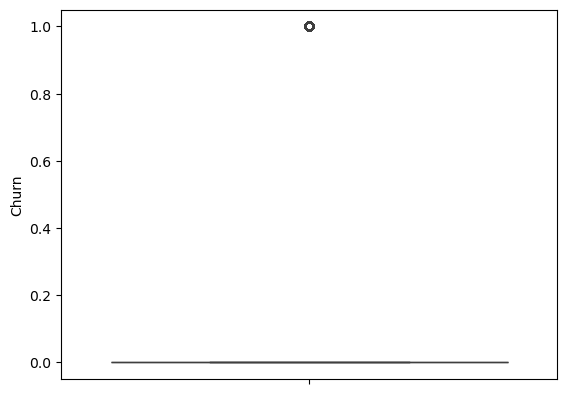

In [23]:

sns.boxplot(df["Churn"])

In [24]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)

# 2. Calculate the IQR
IQR = Q3 - Q1

# 3. Define the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Find the outliers
outliers = df[(df['MonthlyCharges'] < lower_bound) | (df['MonthlyCharges'] > upper_bound)]

print(f"Number of outliers in MonthlyCharges: {len(outliers)}")
print(outliers)

Number of outliers in MonthlyCharges: 0
Empty DataFrame
Columns: [CustomerID, Age, Gender, Region, PlanType, MonthlyCharges, TenureMonths, SupportTickets, AvgMonthlyUsageHours, ContractType, PaymentMethod, AutoPay, SatisfactionScore, LastLoginDays, ReferralCount, DeviceCount, Churn]
Index: []


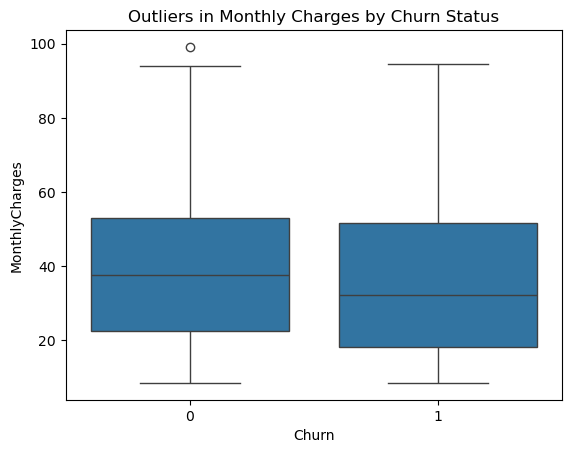

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compare Monthly Charges distribution for those who Churned vs those who stayed
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Outliers in Monthly Charges by Churn Status')
plt.show()

In [26]:
df.head()

,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
0,C0001,35.0,1,South,3,16.62,2.0,5.0,27.0,Quarterly,Card,Yes,4.0,26.0,0.0,1.0,0
1,C0002,26.0,1,North,5,46.23,4.0,0.0,46.1,Monthly,UPI,Yes,5.0,11.0,0.0,2.0,1
2,C0003,31.0,0,North,5,43.04,32.0,0.0,27.2,Monthly,UPI,Yes,7.0,6.0,2.0,3.0,0
3,C0004,34.0,1,East,3,29.19,20.0,4.0,25.1,Monthly,Bank Transfer,Yes,4.0,19.0,0.0,4.0,0
4,C0005,38.0,0,North,3,24.95,1.0,4.0,49.0,Monthly,Cash,No,3.0,25.0,0.0,3.0,1


In [27]:
df['Region'].value_counts()

Region
Central    787
West       705
North      670
South      659
East       659
value       20
Name: count, dtype: int64

In [28]:
# 1. Clean the 'value' noise by replacing it with the Mode (Central)
df['Region'] = df['Region'].replace('value', df['Region'].mode()[0])

# 2. Apply One-Hot Encoding
df = pd.get_dummies(df, columns=['Region'], drop_first=True)

print(df.filter(like='Region').columns)

Index(['Region_East', 'Region_North', 'Region_South', 'Region_West'], dtype='object')


In [29]:
# This will show you the new columns created by get_dummies
print(df.filter(like='Region').head())

# To see counts for a specific new region (e.g., East)
print(df['Region_East'].value_counts())

   Region_East  Region_North  Region_South  Region_West
0        False         False          True        False
1        False          True         False        False
2        False          True         False        False
3         True         False         False        False
4        False          True         False        False
Region_East
False    2841
True      659
Name: count, dtype: int64


In [30]:
# 1. Identify the dummy columns
region_cols = [col for col in df.columns if col.startswith('Region_')]

# 2. Reverse One-Hot Encoding to get the 'Region' column back
# idxmax finds the column with 'True' for each row and strips the 'Region_' prefix
df['Region'] = df[region_cols].idxmax(axis=1).str.replace('Region_', '')

# 3. Drop the old dummy columns now that we have the main one back
df.drop(columns=region_cols, inplace=True)

In [31]:
from sklearn.preprocessing import LabelEncoder

# Initialize and fit the encoder
le = LabelEncoder()
df['Region'] = le.fit_transform(df['Region'])

# Verify the result
print("New Label Encoded Region counts:")
print(df['Region'].value_counts())

New Label Encoded Region counts:
Region
0    1466
3     705
1     670
2     659
Name: count, dtype: int64


In [32]:
df['ContractType'].value_counts()

ContractType
Monthly      1790
Yearly        839
Quarterly     654
1             111
3              49
2              35
value          22
Name: count, dtype: int64

In [33]:
contract_map = {
    'Monthly': 1, '1': 1,
    'Yearly': 2, '2': 2,
    'Quarterly': 3, '3': 3
}

In [34]:
df['ContractType'] = df['ContractType'].astype(str).str.strip().map(contract_map)

In [35]:
df['ContractType'] = (
    df['ContractType']
    .fillna(1)  # Filling with 1 since Monthly is the most frequent
    .astype(int)
)
print(df['ContractType'].value_counts())

ContractType
1    1923
2     874
3     703
Name: count, dtype: int64


In [36]:
df['ContractType'].value_counts()

ContractType
1    1923
2     874
3     703
Name: count, dtype: int64

In [37]:
df['PaymentMethod'].value_counts()

PaymentMethod
Card             1524
Bank Transfer     849
UPI               834
Cash              268
value              25
Name: count, dtype: int64

In [38]:
from sklearn.preprocessing import LabelEncoder

# 1. Clean the noise: Replace 'value' with the Mode ('Card')
df['PaymentMethod'] = df['PaymentMethod'].replace('value', df['PaymentMethod'].mode()[0])

# 2. Initialize and apply LabelEncoder
le_payment = LabelEncoder()
df['PaymentMethod'] = le_payment.fit_transform(df['PaymentMethod'].astype(str))

# 3. Verify the new numeric counts
print("Encoded PaymentMethod counts:")
print(df['PaymentMethod'].value_counts())

Encoded PaymentMethod counts:
PaymentMethod
1    1549
0     849
3     834
2     268
Name: count, dtype: int64


In [39]:
df['PaymentMethod'].value_counts()

PaymentMethod
1    1549
0     849
3     834
2     268
Name: count, dtype: int64

In [40]:
df['AutoPay'].value_counts()

AutoPay
Yes      1915
No       1404
1          94
0          71
value      16
Name: count, dtype: int64

In [41]:
df['AutoPay'] = df['AutoPay'].replace({'Yes': 1, 'No': 0})
df['AutoPay'] = (
    pd.to_numeric(df['AutoPay'], errors='coerce')
    .fillna(df['AutoPay'].mode()[0])
    .astype(int) 
)
print(df['AutoPay'].value_counts())

AutoPay
1    2025
0    1475
Name: count, dtype: int64


In [42]:
df.head()

,CustomerID,Age,Gender,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn,Region
0,C0001,35.0,1,3,16.62,2.0,5.0,27.0,3,1,1,4.0,26.0,0.0,1.0,0,2
1,C0002,26.0,1,5,46.23,4.0,0.0,46.1,1,3,1,5.0,11.0,0.0,2.0,1,1
2,C0003,31.0,0,5,43.04,32.0,0.0,27.2,1,3,1,7.0,6.0,2.0,3.0,0,1
3,C0004,34.0,1,3,29.19,20.0,4.0,25.1,1,0,1,4.0,19.0,0.0,4.0,0,0
4,C0005,38.0,0,3,24.95,1.0,4.0,49.0,1,2,0,3.0,25.0,0.0,3.0,1,1


In [43]:
df.describe()

,Age,Gender,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn,Region
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,36.667143,0.585714,3.907429,40.100946,18.226000,2.996286,43.962486,1.651429,1.310571,0.578571,5.171143,8.557714,1.198571,2.288571,0.162000,1.172286
std,10.183585,0.651966,1.280585,22.194172,16.470072,2.259713,11.891415,0.793072,1.084512,0.493858,2.059038,8.362216,1.349583,0.984960,0.368503,1.176253
min,18.000000,0.000000,0.000000,8.500000,1.000000,0.000000,3.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,0.000000,3.000000,21.607500,6.000000,1.000000,36.000000,1.000000,1.000000,0.000000,4.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,36.000000,1.000000,4.000000,37.585000,13.000000,3.000000,43.700000,1.000000,1.000000,1.000000,5.000000,7.000000,1.000000,2.000000,0.000000,1.000000
75%,43.000000,1.000000,5.000000,52.962500,25.000000,5.000000,51.700000,2.000000,2.000000,1.000000,7.000000,14.000000,2.000000,3.000000,0.000000,2.000000
max,70.000000,3.000000,8.000000,99.150000,72.000000,11.000000,87.500000,3.000000,3.000000,1.000000,10.000000,50.000000,7.000000,6.000000,1.000000,3.000000


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            3500 non-null   object 
 1   Age                   3500 non-null   float64
 2   Gender                3500 non-null   int32  
 3   PlanType              3500 non-null   int32  
 4   MonthlyCharges        3500 non-null   float64
 5   TenureMonths          3500 non-null   float64
 6   SupportTickets        3500 non-null   float64
 7   AvgMonthlyUsageHours  3500 non-null   float64
 8   ContractType          3500 non-null   int32  
 9   PaymentMethod         3500 non-null   int32  
 10  AutoPay               3500 non-null   int32  
 11  SatisfactionScore     3500 non-null   float64
 12  LastLoginDays         3500 non-null   float64
 13  ReferralCount         3500 non-null   float64
 14  DeviceCount           3500 non-null   float64
 15  Churn                

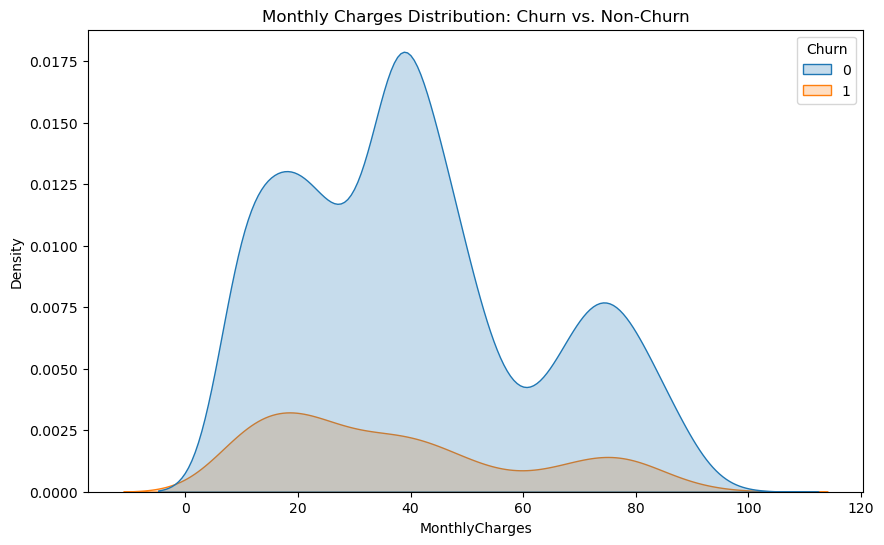

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.title('Monthly Charges Distribution: Churn vs. Non-Churn')
plt.show()

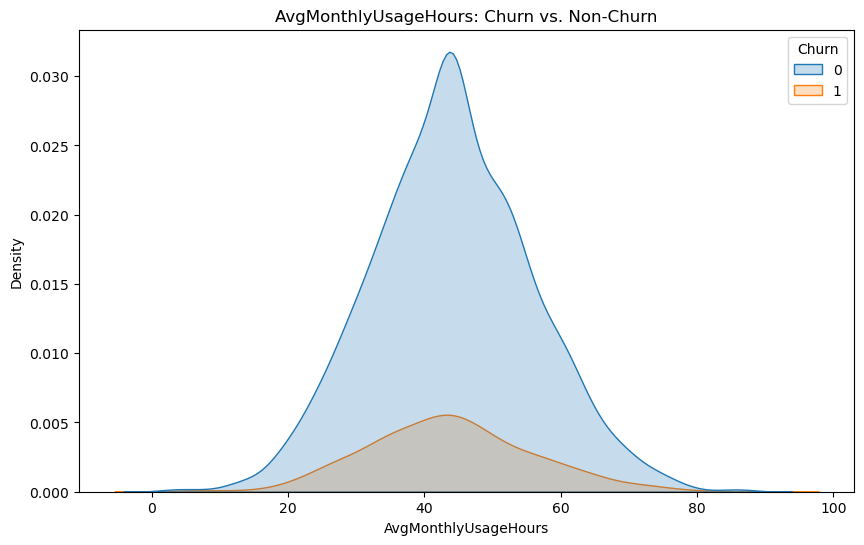

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='AvgMonthlyUsageHours', hue='Churn', fill=True)
plt.title('AvgMonthlyUsageHours: Churn vs. Non-Churn')
plt.show()

In [47]:
# 1. Define the Target (y)
y = df['Churn']

# 2. Define the Features (X)
x = df.drop(columns=['Churn', 'CustomerID'])

In [48]:
x.head()

,Age,Gender,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Region
0,35.0,1,3,16.62,2.0,5.0,27.0,3,1,1,4.0,26.0,0.0,1.0,2
1,26.0,1,5,46.23,4.0,0.0,46.1,1,3,1,5.0,11.0,0.0,2.0,1
2,31.0,0,5,43.04,32.0,0.0,27.2,1,3,1,7.0,6.0,2.0,3.0,1
3,34.0,1,3,29.19,20.0,4.0,25.1,1,0,1,4.0,19.0,0.0,4.0,0
4,38.0,0,3,24.95,1.0,4.0,49.0,1,2,0,3.0,25.0,0.0,3.0,1


In [49]:
y.head()

0    0
1    1
2    0
3    0
4    1
Name: Churn, dtype: int64

In [50]:
x.corr()

,Age,Gender,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Region
Age,1.000000,-0.002395,-0.037669,-0.028064,-0.009322,0.014763,-0.005865,0.030607,0.015677,-0.014773,-0.011853,0.025200,0.027602,0.012713,-0.020454
Gender,-0.002395,1.000000,0.000264,-0.013901,0.026262,0.012340,-0.000641,-0.028426,0.002962,-0.009827,0.012169,0.024936,-0.002622,-0.007820,-0.001933
PlanType,-0.037669,0.000264,1.000000,0.317344,-0.016691,-0.317741,0.051691,0.010711,-0.018804,0.002918,0.152009,-0.146368,0.026349,0.046562,0.011919
MonthlyCharges,-0.028064,-0.013901,0.317344,1.000000,-0.004518,-0.430964,0.341430,0.038972,0.000192,-0.010508,0.225569,-0.186059,0.199898,0.353632,0.006074
TenureMonths,-0.009322,0.026262,-0.016691,-0.004518,1.000000,0.006281,0.000172,-0.036655,-0.002923,0.018213,0.002828,-0.216807,0.002712,0.031161,-0.005462
SupportTickets,0.014763,0.012340,-0.317741,-0.430964,0.006281,1.000000,-0.117335,-0.001679,0.006885,0.007816,-0.508209,0.433276,-0.119337,-0.127667,-0.003307
AvgMonthlyUsageHours,-0.005865,-0.000641,0.051691,0.341430,0.000172,-0.117335,1.000000,-0.012536,-0.027708,-0.017998,0.059746,-0.051632,0.103035,0.163605,-0.007762
ContractType,0.030607,-0.028426,0.010711,0.038972,-0.036655,-0.001679,-0.012536,1.000000,-0.007677,-0.005212,0.074171,-0.028080,0.005943,0.019046,0.024261
PaymentMethod,0.015677,0.002962,-0.018804,0.000192,-0.002923,0.006885,-0.027708,-0.007677,1.000000,-0.019160,0.016122,0.000465,0.014675,0.009718,-0.025602
AutoPay,-0.014773,-0.009827,0.002918,-0.010508,0.018213,0.007816,-0.017998,-0.005212,-0.019160,1.000000,0.006025,-0.006946,-0.003048,0.016241,-0.003384


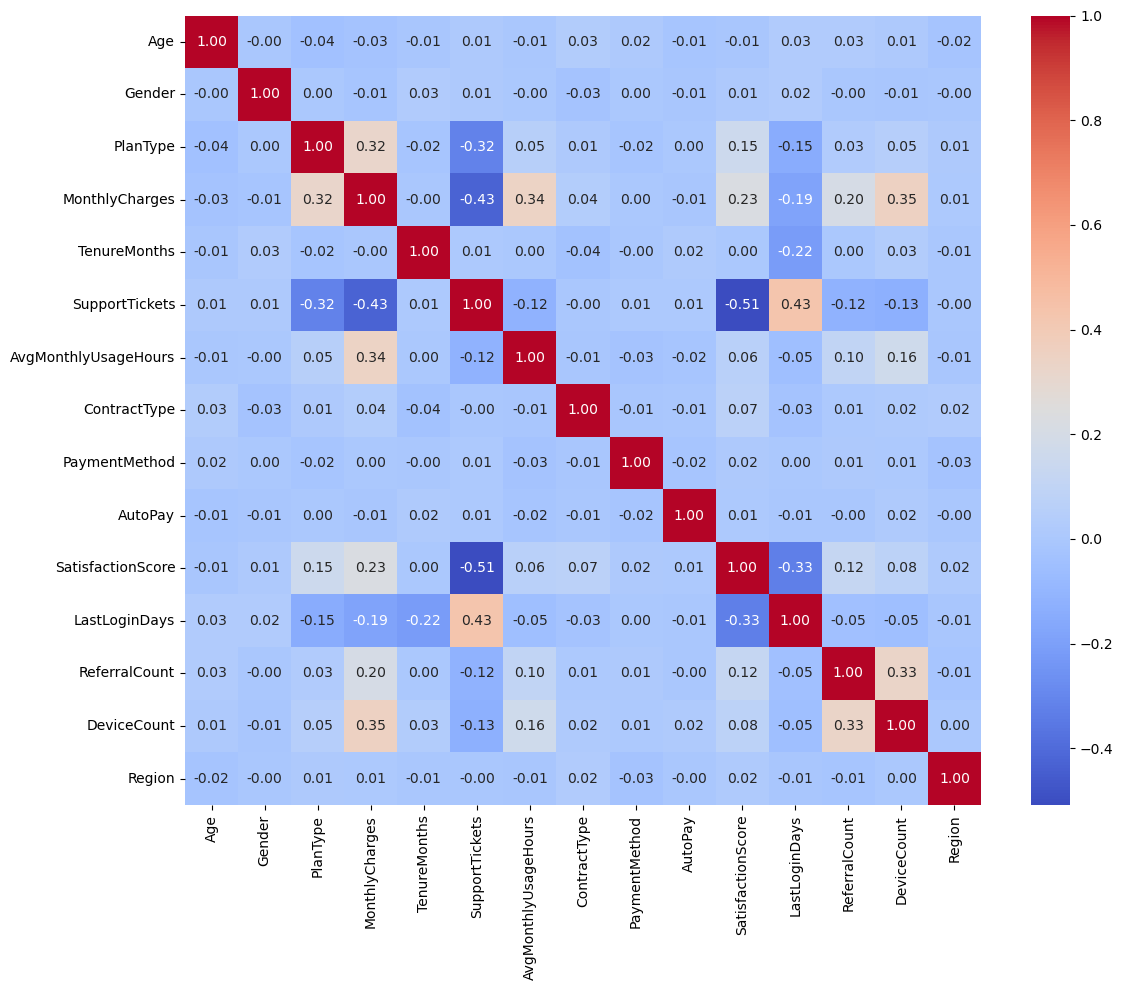

In [51]:
# Set the figure size (width, height in inches)
plt.figure(figsize=(12, 10))

# Create the heatmap
sns.heatmap(x.corr(), annot=True, fmt=".2f", cmap='coolwarm')

# Optional: Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

In [52]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest= train_test_split(x,y, test_size=.2, random_state=42)

In [53]:
Xtrain.shape, Xtest.shape, Ytrain.shape, Ytest.shape

((2800, 15), (700, 15), (2800,), (700,))

In [54]:
print(df['Churn'].value_counts())

Churn
0    2933
1     567
Name: count, dtype: int64


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
log_reg = LogisticRegression() 
log_reg.fit(Xtrain, Ytrain)

c:\Users\Windows 11-Pro Edu\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [56]:
y_pred = log_reg.predict(Xtest)

In [57]:
print(f"Accuracy: {accuracy_score(Ytest, y_pred)}")

Accuracy: 0.84


In [58]:
print(classification_report(Ytest, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       568
           1       0.69      0.27      0.39       132

    accuracy                           0.84       700
   macro avg       0.77      0.62      0.65       700
weighted avg       0.82      0.84      0.81       700



In [59]:
cm = confusion_matrix(Ytest, y_pred)
cm

array([[552,  16],
       [ 96,  36]], dtype=int64)

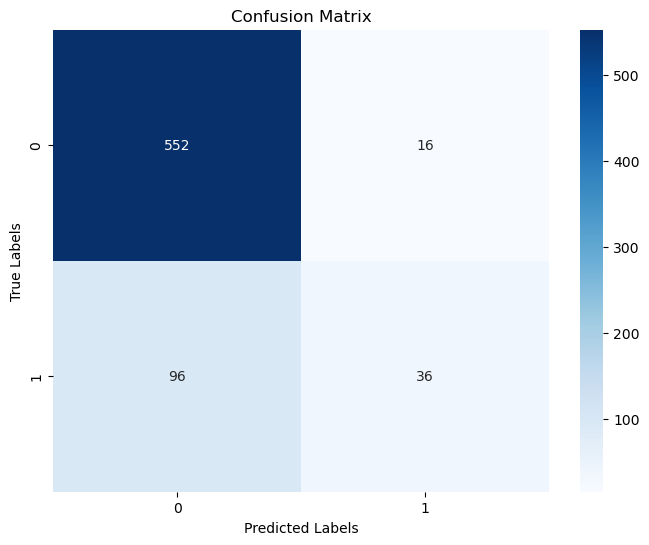

In [60]:
# 1. Set the figure size (e.g., 8 inches wide, 6 inches tall)
plt.figure(figsize=(8, 6))

# 2. Create the heatmap
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")

# 3. Add labels for clarity
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

# 4. Show the plot
plt.show()

In [61]:
pred_proba = log_reg.predict_proba(Xtest)
pred_proba

array([[0.90656229, 0.09343771],
       [0.99552435, 0.00447565],
       [0.51975396, 0.48024604],
       ...,
       [0.87661542, 0.12338458],
       [0.88674625, 0.11325375],
       [0.94623068, 0.05376932]])

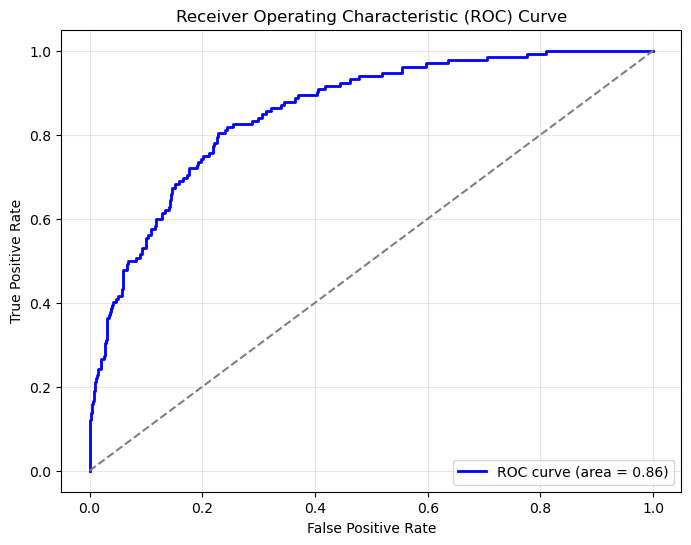

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get prediction probabilities
# predict_proba returns a 2D array: [prob_of_0, prob_of_1]
pred_proba = log_reg.predict_proba(Xtest)

# 2. Select only the probabilities for the positive class (Churn = 1)
# This is the second column (index 1)
y_scores = pred_proba[:, 1]

# 3. Calculate FPR, TPR, and AUC using the positive class scores
fpr, tpr, thresholds = roc_curve(Ytest, y_scores)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [63]:
x.head()

,Age,Gender,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Region
0,35.0,1,3,16.62,2.0,5.0,27.0,3,1,1,4.0,26.0,0.0,1.0,2
1,26.0,1,5,46.23,4.0,0.0,46.1,1,3,1,5.0,11.0,0.0,2.0,1
2,31.0,0,5,43.04,32.0,0.0,27.2,1,3,1,7.0,6.0,2.0,3.0,1
3,34.0,1,3,29.19,20.0,4.0,25.1,1,0,1,4.0,19.0,0.0,4.0,0
4,38.0,0,3,24.95,1.0,4.0,49.0,1,2,0,3.0,25.0,0.0,3.0,1
